##### 1. Image Processing and Enhancement

Blurring an Image


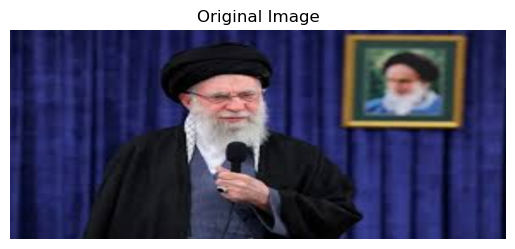

In [2]:
import cv2
from matplotlib import pyplot as plt
image_path = 'C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg'
image = cv2.imread(image_path)
resized_image = cv2.resize(image, (1900, 800))
resized_image_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)
plt.imshow(resized_image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

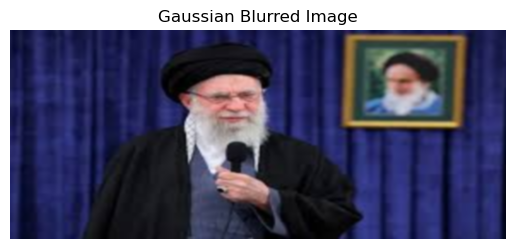

In [3]:
Gaussian = cv2.GaussianBlur(resized_image, (15, 15), 0)  
Gaussian_rgb = cv2.cvtColor(Gaussian, cv2.COLOR_BGR2RGB)  
plt.imshow(Gaussian_rgb)
plt.title('Gaussian Blurred Image')
plt.axis('off')
plt.show()

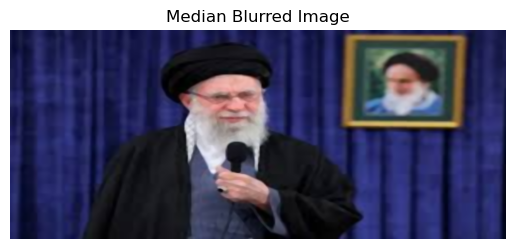

In [5]:
median = cv2.medianBlur(resized_image, 11)  
median_rgb = cv2.cvtColor(median, cv2.COLOR_BGR2RGB)  

plt.imshow(median_rgb)
plt.title('Median Blurred Image')
plt.axis('off')
plt.show()

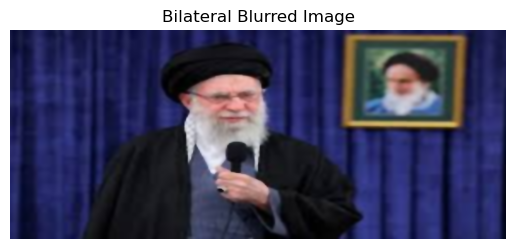

In [6]:
bilateral = cv2.bilateralFilter(resized_image, 15, 150, 150)  
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB)  

plt.imshow(bilateral_rgb)
plt.title('Bilateral Blurred Image')
plt.axis('off')
plt.show()

Grayscaling of Images


In [7]:
import cv2

image = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2.imshow('Grayscale', gray_image)
cv2.waitKey(0)  
cv2.destroyAllWindows()

In [8]:
import cv2

img = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg', 0)

cv2.imshow('Grayscale Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [9]:
import cv2

img_weighted = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
rows, cols = img_weighted.shape[:2]

for i in range(rows):
    for j in range(cols):
        gray = 0.2989 * img_weighted[i, j][2] + 0.5870 * img_weighted[i, j][1] + 0.1140 * img_weighted[i, j][0]
        img_weighted[i, j] = [gray, gray, gray]

cv2.imshow('Grayscale Image (Weighted)', img_weighted)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
import cv2

img = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
rows, cols = img.shape[:2]

for i in range(rows):
    for j in range(cols):
        gray = (img[i, j, 0] + img[i, j, 1] + img[i, j, 2]) / 3
        img[i, j] = [gray, gray, gray]

cv2.imshow('Grayscale Image (Average)', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

C:\Users\M.Rameez\AppData\Local\Temp\ipykernel_16200\3684677401.py:8: RuntimeWarning: overflow encountered in scalar add
  gray = (img[i, j, 0] + img[i, j, 1] + img[i, j, 2]) / 3


Scaling, Rotating, Shifting and Edge Detection


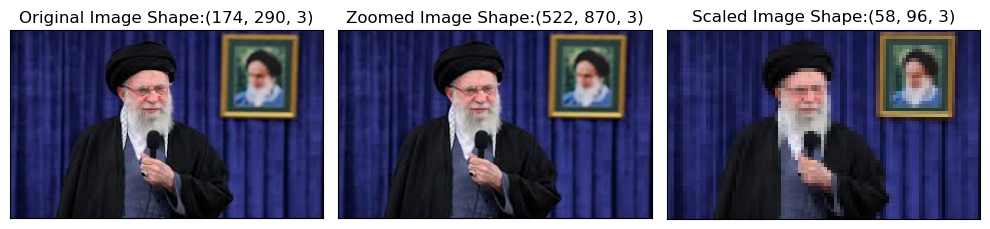

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
scale_factor_1 = 3.0  
scale_factor_2 = 1/3.0
height, width = image_rgb.shape[:2]
new_height = int(height * scale_factor_1)
new_width = int(width * scale_factor_1)

zoomed_image = cv2.resize(src =image_rgb, 
                          dsize=(new_width, new_height), 
                          interpolation=cv2.INTER_CUBIC)
                          
new_height1 = int(height * scale_factor_2)
new_width1 = int(width * scale_factor_2)
scaled_image = cv2.resize(src= image_rgb, 
                          dsize =(new_width1, new_height1), 
                          interpolation=cv2.INTER_AREA)

fig, axs = plt.subplots(1, 3, figsize=(10, 4))
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image Shape:'+str(image_rgb.shape))
axs[1].imshow(zoomed_image)
axs[1].set_title('Zoomed Image Shape:'+str(zoomed_image.shape))
axs[2].imshow(scaled_image)
axs[2].set_title('Scaled Image Shape:'+str(scaled_image.shape))

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

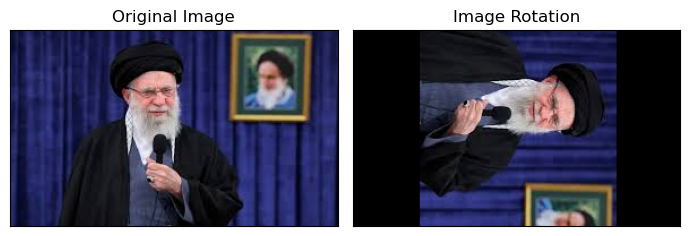

In [15]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
center = (image_rgb.shape[1] // 2, image_rgb.shape[0] // 2)
angle = 270
scale = 1
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
rotated_image = cv2.warpAffine(image_rgb, rotation_matrix, (img.shape[1], img.shape[0]))

fig, axs = plt.subplots(1, 2, figsize=(7, 4))
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')
axs[1].imshow(rotated_image)
axs[1].set_title('Image Rotation')
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.tight_layout()
plt.show()

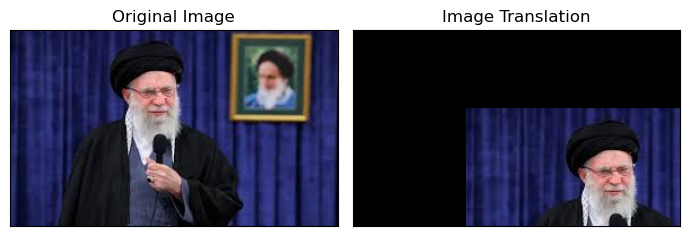

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
width, height = image_rgb.shape[1], image_rgb.shape[0]

tx, ty = 100, 70
translation_matrix = np.array([[1, 0, tx], [0, 1, ty]], dtype=np.float32)
translated_image = cv2.warpAffine(image_rgb, translation_matrix, (width, height))

fig, axs = plt.subplots(1, 2, figsize=(7, 4))
axs[0].imshow(image_rgb), axs[0].set_title('Original Image')
axs[1].imshow(translated_image), axs[1].set_title('Image Translation')

for ax in axs:
    ax.set_xticks([]), ax.set_yticks([])

plt.tight_layout()
plt.show()

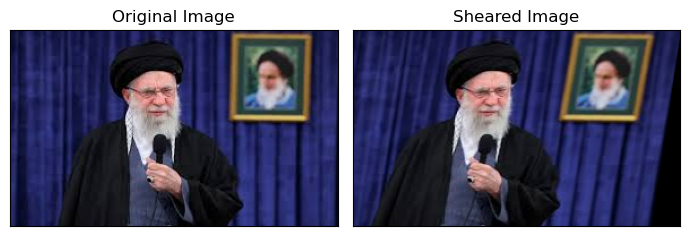

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
width, height = image_rgb.shape[1], image_rgb.shape[0]

shearX, shearY = -0.15, 0
transformation_matrix = np.array([[1, shearX, 0], [0, 1, shearY]], dtype=np.float32)
sheared_image = cv2.warpAffine(image_rgb, transformation_matrix, (width, height))

fig, axs = plt.subplots(1, 2, figsize=(7, 4))
axs[0].imshow(image_rgb), axs[0].set_title('Original Image')
axs[1].imshow(sheared_image), axs[1].set_title('Sheared Image')

for ax in axs:
    ax.set_xticks([]), ax.set_yticks([])

plt.tight_layout()
plt.show()

[[0.09019608 0.03529412 0.02745098 ... 0.07843137 0.06666667 0.06666667]
 [0.09019608 0.03529412 0.02745098 ... 0.07843137 0.07058824 0.07058824]
 [0.09411765 0.03921569 0.03137255 ... 0.07843137 0.07058824 0.07058824]
 ...
 [0.12156863 0.1372549  0.15294118 ... 0.05882353 0.00392157 0.00784314]
 [0.11764706 0.13333333 0.15294118 ... 0.05882353 0.00392157 0.00784314]
 [0.11764706 0.13333333 0.14901961 ... 0.05490196 0.00392157 0.00784314]]


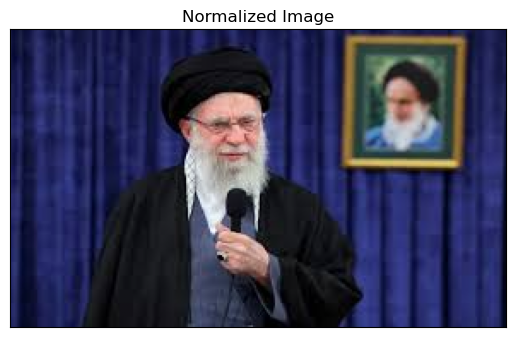

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
b, g, r = cv2.split(image_rgb)

b_normalized = cv2.normalize(b.astype('float'), None, 0, 1, cv2.NORM_MINMAX)
g_normalized = cv2.normalize(g.astype('float'), None, 0, 1, cv2.NORM_MINMAX)
r_normalized = cv2.normalize(r.astype('float'), None, 0, 1, cv2.NORM_MINMAX)

normalized_image = cv2.merge((b_normalized, g_normalized, r_normalized))
print(normalized_image[:, :, 0])

plt.imshow(normalized_image)
plt.xticks([]), 
plt.yticks([]), 
plt.title('Normalized Image')
plt.show()

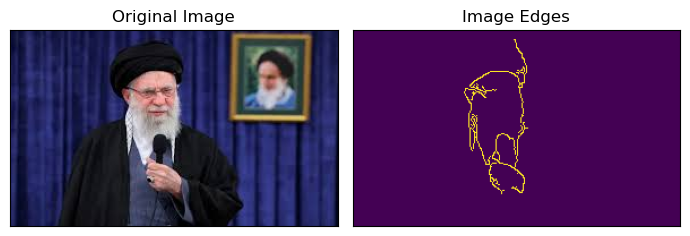

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
edges = cv2.Canny(image_rgb, 100, 700)

fig, axs = plt.subplots(1, 2, figsize=(7, 4))
axs[0].imshow(image_rgb), axs[0].set_title('Original Image')
axs[1].imshow(edges), axs[1].set_title('Image Edges')

for ax in axs:
    ax.set_xticks([]), ax.set_yticks([])

plt.tight_layout()
plt.show()

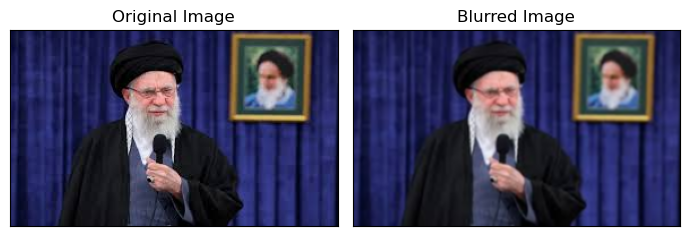

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
blurred = cv2.GaussianBlur(image, (3, 3), 0)
blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(7, 4))
axs[0].imshow(image_rgb), axs[0].set_title('Original Image')
axs[1].imshow(blurred_rgb), axs[1].set_title('Blurred Image')

for ax in axs:
    ax.set_xticks([]), ax.set_yticks([])

plt.tight_layout()
plt.show()

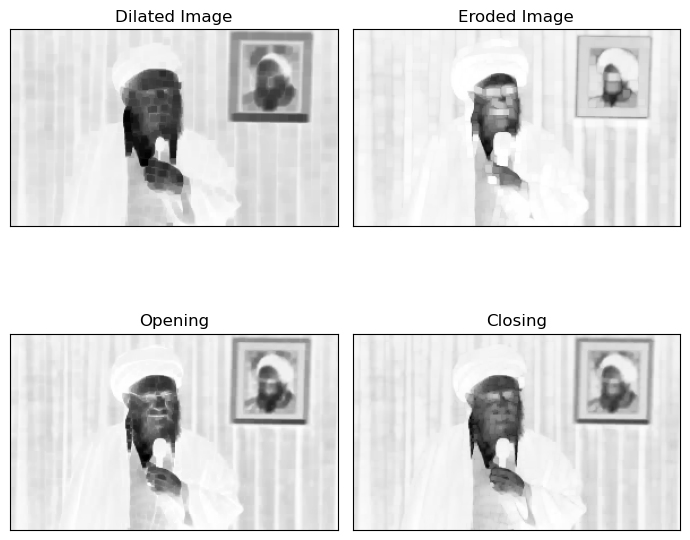

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('C:/Users/M.Rameez/OneDrive/Desktop/Tasks/task 5/opencv/1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
kernel = np.ones((3, 3), np.uint8)

dilated = cv2.dilate(image_gray, kernel, iterations=2)
eroded = cv2.erode(image_gray, kernel, iterations=2)
opening = cv2.morphologyEx(image_gray, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image_gray, cv2.MORPH_CLOSE, kernel)

fig, axs = plt.subplots(2, 2, figsize=(7, 7))
axs[0, 0].imshow(dilated, cmap='Greys'), axs[0, 0].set_title('Dilated Image')
axs[0, 1].imshow(eroded, cmap='Greys'), axs[0, 1].set_title('Eroded Image')
axs[1, 0].imshow(opening, cmap='Greys'), axs[1, 0].set_title('Opening')
axs[1, 1].imshow(closing, cmap='Greys'), axs[1, 1].set_title('Closing')

for ax in axs.flatten():
    ax.set_xticks([]), ax.set_yticks([])

plt.tight_layout()
plt.show()

# Intensity Transformation Operations on Images


In [5]:
import cv2
import numpy as np
img = cv2.imread('sample.jpg')
c = 255/(np.log(1 + np.max(img)))
log_transformed = c * np.log(1 + img)
log_transformed = np.array(log_transformed, dtype = np.uint8)
cv2.imwrite('log_transformed.jpg', log_transformed)

True

In [6]:
import cv2
import numpy as np
img = cv2.imread('sample.jpg')
for gamma in [0.1, 0.5, 1.2, 2.2]:
    gamma_corrected = np.array(255*(img / 255) ** gamma, dtype = 'uint8')
    cv2.imwrite('gamma_transformed'+str(gamma)+'.jpg', gamma_corrected)

In [7]:
import cv2
import numpy as np
def pixelVal(pix, r1, s1, r2, s2):
    if (0 <= pix and pix <= r1):
        return (s1 / r1)*pix
    elif (r1 < pix and pix <= r2):
        return ((s2 - s1)/(r2 - r1)) * (pix - r1) + s1
    else:
        return ((255 - s2)/(255 - r2)) * (pix - r2) + s2
img = cv2.imread('sample.jpg')
r1 = 70
s1 = 0
r2 = 140
s2 = 255
pixelVal_vec = np.vectorize(pixelVal)
contrast_stretched = pixelVal_vec(img, r1, s1, r2, s2)
cv2.imwrite('contrast_stretch.jpg', contrast_stretched)

True

# Image Translation


In [ ]:
import cv2
import numpy as np
image = cv2.imread('sample.jpg')
height, width = image.shape[:2]
quarter_height, quarter_width = height / 4, width / 4
T = np.float32([[1, 0, quarter_width], [0, 1, quarter_height]])
img_translation = cv2.warpAffine(image, T, (width, height))
cv2.imshow("Original Image", image)
cv2.imshow("Translated Image", img_translation)
cv2.waitKey(0)
cv2.destroyAllWindows()

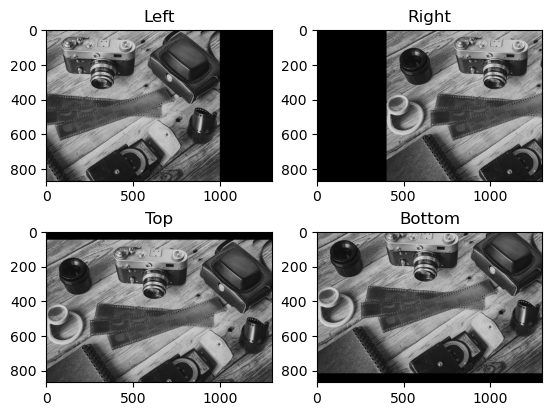

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('sample.jpg')
rows, cols, _ = img.shape

M_left = np.float32([[1, 0, -300], [0, 1, 0]])
M_right = np.float32([[1, 0, 400], [0, 1, 0]])
M_top = np.float32([[1, 0, 0], [0, 1, 50]])
M_bottom = np.float32([[1, 0, 0], [0, 1, -50]])

img_left = cv2.warpAffine(img, M_left, (cols, rows))
img_right = cv2.warpAffine(img, M_right, (cols, rows))
img_top = cv2.warpAffine(img, M_top, (cols, rows))
img_bottom = cv2.warpAffine(img, M_bottom, (cols, rows))

plt.subplot(221), plt.imshow(img_left), plt.title('Left')
plt.subplot(222), plt.imshow(img_right), plt.title('Right')
plt.subplot(223), plt.imshow(img_top), plt.title('Top')
plt.subplot(224), plt.imshow(img_bottom), plt.title('Bottom')
plt.show()

# Image Pyramid


In [20]:
import cv2
import numpy as np

image = cv2.imread('P1.webp')

downsampled_image = cv2.pyrDown(image)

cv2.imshow("Original Image", image)
cv2.imshow("Downsampled Image", downsampled_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [21]:
import cv2
import numpy as np

image = cv2.imread('P1.webp')

upsampled_image = cv2.pyrUp(image)

cv2.imshow("Original Image", image)
cv2.imshow("Upsampled Image", upsampled_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [22]:
import cv2
import numpy as np

image = cv2.imread('P1.webp')

pyramid = [image]

for i in range(3):
    image = cv2.pyrDown(image)
    pyramid.append(image)

for i in range(len(pyramid)-1, -1, -1):
    print(f"Pyramid Level {i}")
    
    cv2.imshow(f"Pyramid Level {i}", pyramid[i])
    cv2.waitKey(0)

cv2.destroyAllWindows()

Pyramid Level 3
Pyramid Level 2
Pyramid Level 1
Pyramid Level 0


# Histograms Equalization


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [26]:
img = cv2.imread('1.jpg', 0)  
equ = cv2.equalizeHist(img)
res = np.hstack((img, equ))

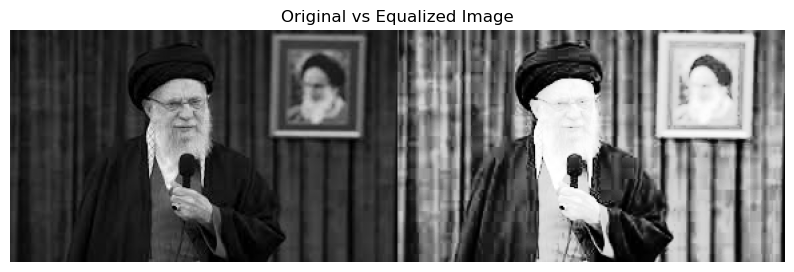

In [27]:
plt.figure(figsize=(10, 5))
plt.imshow(res, cmap='gray')  
plt.title("Original vs Equalized Image")
plt.axis('off')  
plt.show()

# Convert an image from one color space to another


In [29]:
import cv2
src = cv2.imread(r'LOGO.png')  # Read the image

# Convert to Grayscale
gray_image = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

# Display
cv2.imshow("Grayscale Image", gray_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [30]:
import cv2
src = cv2.imread(r'LOGO.png')

# Convert to HSV
hsv_image = cv2.cvtColor(src, cv2.COLOR_BGR2HSV)

cv2.imshow("HSV Image", hsv_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

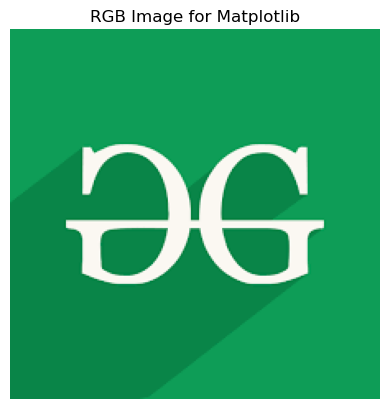

In [31]:
import cv2
import matplotlib.pyplot as plt
src = cv2.imread(r'LOGO.png')

# Convert from BGR to RGB
rgb_image = cv2.cvtColor(src, cv2.COLOR_BGR2RGB)

# Display with Matplotlib
plt.imshow(rgb_image)
plt.title("RGB Image for Matplotlib")
plt.axis('off')
plt.show()

# Visualizing image in different color spaces


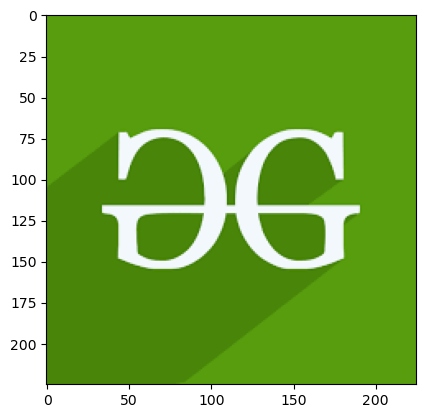

In [32]:
# Python program to read image as RGB

# Importing cv2 and matplotlib module
import cv2
import matplotlib.pyplot as plt

# reads image as RGB
img = cv2.imread('LOGO.png')

# shows the image
plt.imshow(img)

In [33]:
# Python program to read image as GrayScale

# Importing cv2 module
import cv2

# Reads image as gray scale
img = cv2.imread('LOGO.png', 0) 

# We can alternatively convert
# image by using cv2color
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Shows the image
cv2.imshow('image', img) 

cv2.waitKey(0)         
cv2.destroyAllWindows()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<3,4,-1>,struct cv::impl::A0xb1d3297b::Set<1,-1,-1>,struct cv::impl::A0xb1d3297b::Set<0,2,5>,4>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 1
